## 动量策略

In [40]:
#1加载数据
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance  as mpf
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')
# 修改列名
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount']
missing_values = df.isnull().sum()
print('缺失值的数量:',missing_values)

缺失值的数量: Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Amount    0
dtype: int64


In [41]:
#计算RSI指标
def calculate_rsi(data,window = 14):
    delta = df['Close'].diff()
    gain = delta.copy()
    loss = delta.copy()
    gain[gain < 0] = 0
    loss[loss > 0] = 0
    avg_gain = gain.rolling(window).mean()
    avg_loss = abs(loss.rolling(window).mean())
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
    

In [42]:
#调用函数计算RSI
df['RSI']  = calculate_rsi(df)
print(df['RSI'])

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
237    40.436311
238    41.290118
239    41.303200
240    54.140022
241    55.920162
Name: RSI, Length: 242, dtype: float64


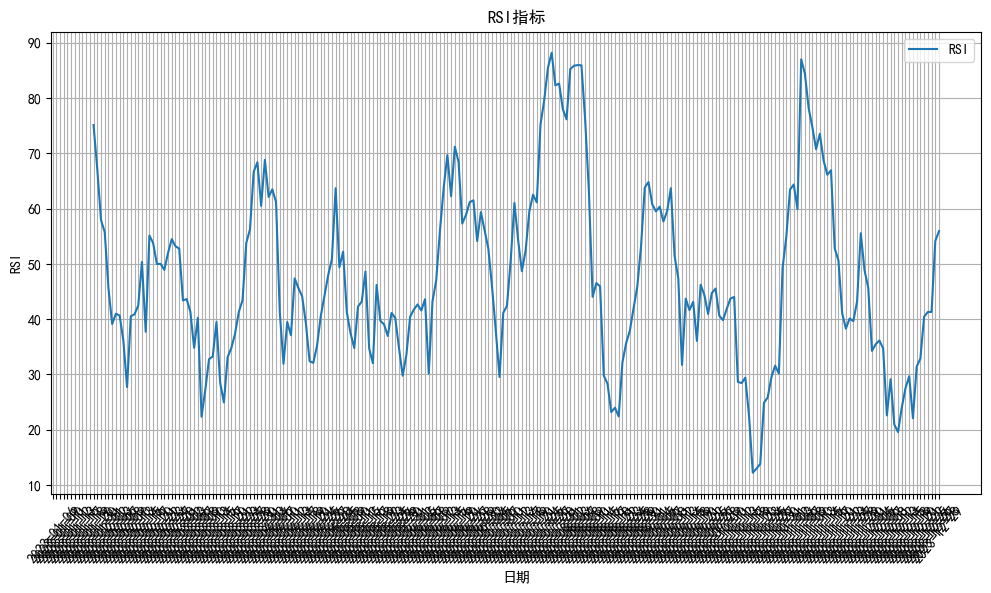

In [43]:
#绘图
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
rsi = calculate_rsi(df)
plt.figure(figsize=(12,6),dpi=100)
plt.plot(df['Date'],rsi,label = 'RSI')
plt.title('RSI指标')
plt.xlabel('日期')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=50)
plt.show()

## 生成交易信号

In [44]:
df['Signal'] = 0
df.loc[df['RSI'] > 70 ,'Signal'] = -1
df.loc[df['RSI'] < 30 , 'Signal'] = 1
print(df['Signal'])

0      0
1      0
2      0
3      0
4      0
      ..
237    0
238    0
239    0
240    0
241    0
Name: Signal, Length: 242, dtype: int64


## 绘制K线图

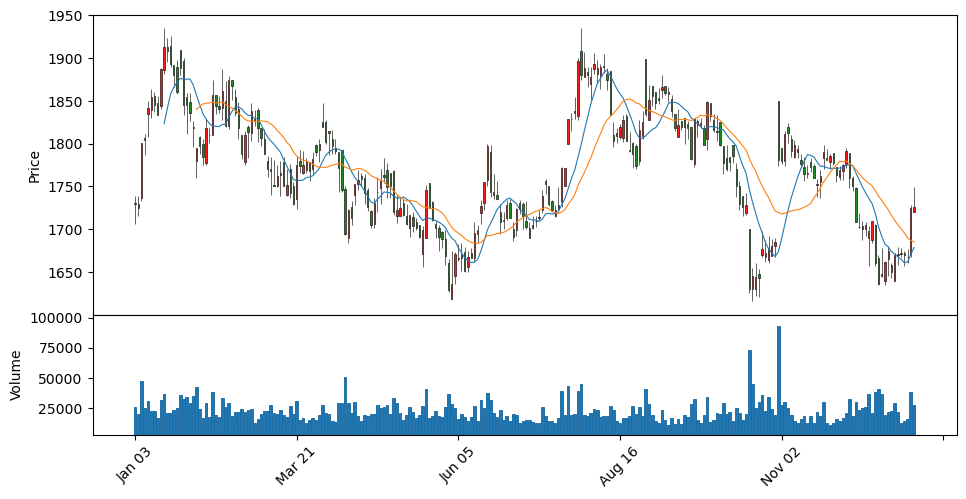

In [45]:
import matplotlib.pyplot as plt
import mplfinance  as mpf
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv('C:/Users/86157/Desktop/茅台2023年股价.csv')
# 修改列名
df.columns = ['Date','Open', 'High', 'Low', 'Close','Volume','Amount']
# 处理日期格式并设置为索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)
# 设置K线颜色
market_colors = mpf.make_marketcolors(up='red', down='green')
my_style = mpf.make_mpf_style(marketcolors=market_colors)
#绘图
mpf.plot(df,type ='candle',figsize=(12,6),mav=(10,20),volume = True,style=my_style)


## 绘制价格和交易信号图

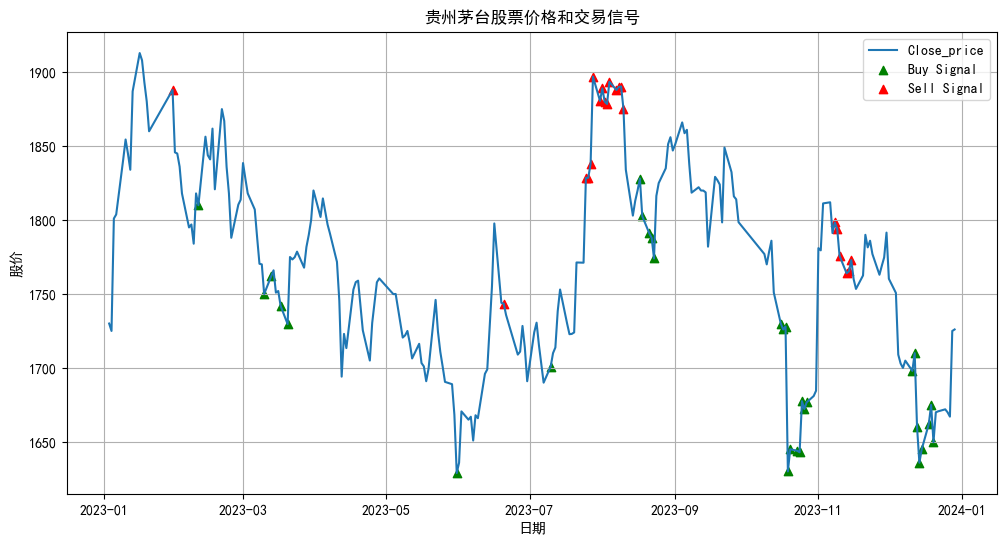

In [52]:
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
df['RSI']  = calculate_rsi(df)
df['Signal'] = 0
df.loc[df['RSI'] > 70 ,'Signal'] = -1
df.loc[df['RSI'] < 30 , 'Signal'] = 1
# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close_price')  # 使用索引作为x轴（日期）
plt.scatter(df[df['Signal'] == 1].index ,df[df['Signal'] == 1]['Close'],color = 'green',marker = '^',label = 'Buy Signal')
plt.scatter(df[df['Signal'] == -1].index ,df[df['Signal'] == -1]['Close'],color = 'red',marker = '^',label = 'Sell Signal')
plt.title('贵州茅台股票价格和交易信号')
plt.xlabel('日期')
plt.ylabel('股价')  # 修正了拼写错误
plt.legend()
plt.grid(True)

# 自动调整日期标签的显示格式，避免重叠

plt.show()

## 美化后的代码

D:\anaconda\envs\financial-ml\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\financial-ml\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\financial-ml\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\financial-ml\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\financial-ml\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missin

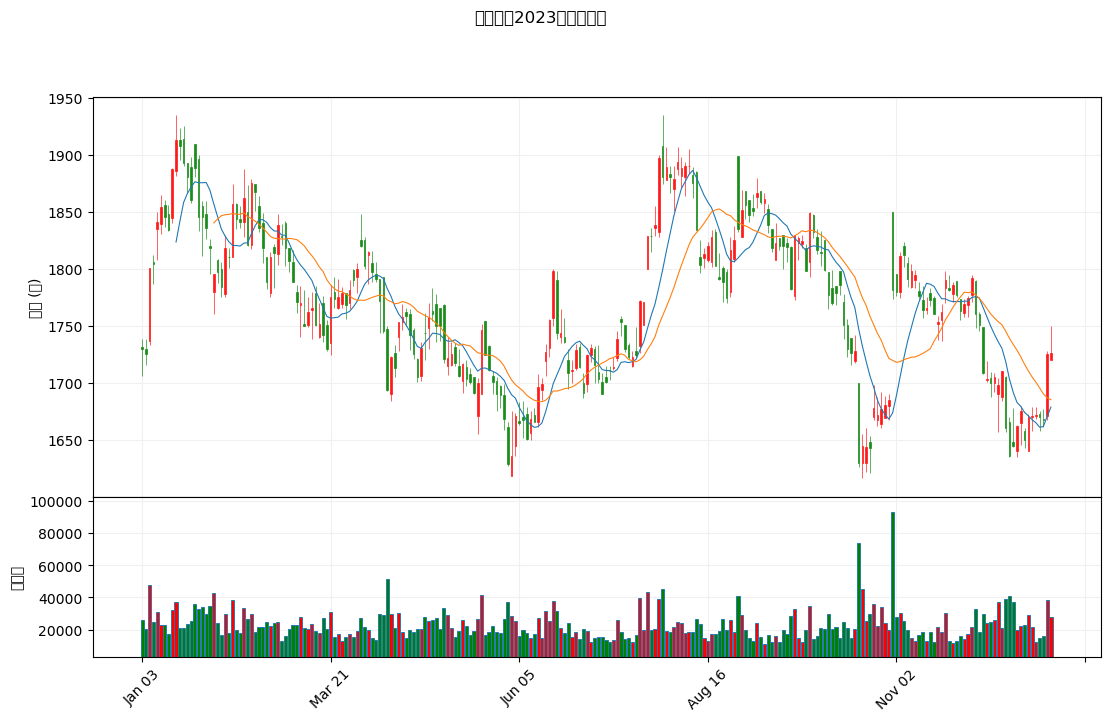

<Figure size 640x480 with 0 Axes>

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# 设置中文字体，确保图表中文正常显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

def plot_stock_chart(csv_path):
    """
    绘制股票K线图
    
    参数:
        csv_path: 股票数据CSV文件路径
    """
    try:
        # 读取CSV数据
        df = pd.read_csv(csv_path)
        
        # 数据预处理
        # 修改列名以匹配mplfinance要求
        df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Amount']
        
        # 转换日期格式并设置为索引
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        
        # 确保数值列是浮点型，避免绘图错误
        numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Amount']
        df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
        
        # 配置K线图样式
        # 上涨为红色，下跌为绿色
        market_colors = mpf.make_marketcolors(
            up='red', 
            down='green',
            edge='i',       # 蜡烛边缘颜色与实体一致
            wick='i',       # 蜡烛影线颜色与实体一致
            volume='in'     # 成交量颜色与K线一致
        )
        
        # 创建自定义样式
        my_style = mpf.make_mpf_style(
            marketcolors=market_colors,
            figcolor='white',       # 图表背景色
            gridcolor='#f0f0f0'     # 网格线颜色
        )
        
        # 绘制K线图
        # 包含10日和20日均线，显示成交量
        mpf.plot(
            df,
            type='candle',          # 蜡烛图类型
            figsize=(14, 8),        # 图表大小
            mav=(10, 20),           # 移动平均线
            volume=True,            # 显示成交量
            style=my_style,         # 应用自定义样式
            title='贵州茅台2023年股价走势',  # 图表标题
            ylabel='价格 (元)',      # 价格轴标签
            ylabel_lower='成交量',   # 成交量轴标签
            show_nontrading=False   # 不显示非交易日
        )
        
        plt.tight_layout()  # 调整布局，避免标签被截断
        plt.show()
        
    except FileNotFoundError:
        print(f"错误: 找不到文件 '{csv_path}'")
    except Exception as e:
        print(f"绘图过程中发生错误: {str(e)}")

# 主程序执行
if __name__ == "__main__":
    # 股票数据文件路径
    stock_data_path = "C:/Users/86157/Desktop/茅台2023年股价.csv"
    # 绘制K线图
    plot_stock_chart(stock_data_path)